In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from tqdm.notebook import tqdm

## Prep Dataset

tensor_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = MNIST(root='./data',train=True,transform=tensor_transform,download=True)
test_dataset = MNIST(root='./data',train=True,transform=tensor_transform,download=True)


## Set Device

device = "cuda" if torch.cuda.is_available() else "cpu"

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 605kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.23MB/s]


# Standard Vector Qunatizer

In [ ]:
class VectorQuantizer(nn.Module):
    def __init__(self, codebook_size=1024, latent_dim=2):
        super().__init__()

        self.embedding = nn.Embedding(codebook_size, latent_dim)
        self.embedding.weight.data.uniform_(-1/codebook_size, 1/codebook_size)

        self.latent_dim = latent_dim
        self.codebook_size = codebook_size

    def forward(self, x):

        batch_size = x.shape[0]

        ### Distance btwn every Latent and Code: (L-C)**2 = (L**2 - 2LC + C**2 ) ###

        ### L2: [B, L] -> [B, 1]
        L2 = torch.sum(x**2, dim=1, keepdim=True)

        ### C2: [C, L] -> [C]
        C2 = torch.sum(self.embedding.weight**2, dim=1).unsqueeze(0)

        ### CL: [B,L]@[L,C] -> [B, C]
        CL = x@self.embedding.weight.t()

        ### [B, 1] - 2 * [B, C] + [C] -> [B, C]
        distances = L2 - 2*CL + C2

        ### Grab Closest Indexes, create matrix of corresponding vectors ###
        ### Closest: [B, 1]
        closest = torch.argmin(distances, dim=-1)

        ### Create Empty Quantized Latents Embedding ###
        # latents_idx: [B, C]
        quantized_latents_idx = torch.zeros(batch_size, self.codebook_size, device=x.device)

        ### Place a 1 at the Indexes for each sample for the codebook we want ###
        batch_idx = torch.arange(batch_size)
        quantized_latents_idx[batch_idx,closest] = 1

        ### Matrix Multiplication to Grab Indexed Latents from Embeddings ###

        # quantized_latents: [B, C] @ [C, L] -> [B, L]
        quantized_latents = quantized_latents_idx @ self.embedding.weight

        return quantized_latents, closest

vq = VectorQuantizer(codebook_size=512,latent_dim=8)
rand = torch.randn(1024,8)
vq(rand)

(tensor([[ 9.5435e-04,  1.1575e-03, -1.4577e-03,  ..., -5.0731e-04,
           1.8701e-03,  1.9098e-03],
         [-1.9161e-03, -1.9383e-03, -1.0042e-03,  ...,  1.8794e-03,
          -9.2248e-04,  7.2359e-04],
         [-1.1572e-03, -1.2864e-03, -1.7730e-03,  ..., -1.3142e-03,
           1.2082e-03,  1.3065e-03],
         ...,
         [-1.0097e-03, -1.1111e-03, -7.2044e-04,  ...,  9.1918e-04,
           1.8482e-03,  1.3513e-03],
         [-1.8547e-03, -1.0930e-03,  1.9419e-03,  ..., -1.5827e-03,
           1.8952e-04, -9.9106e-04],
         [ 1.9156e-04,  1.5882e-03, -1.9034e-03,  ...,  6.7696e-05,
           1.0308e-03, -1.3544e-03]], grad_fn=<MmBackward0>),
 tensor([214, 366,  89,  ..., 360, 172, 393]))

# Implement a Linear RVQ

In [ ]:
class LinearResidualVectorQuantizedVAE(nn.Module):
    def __init__(self, latent_dim=2, codebook_size=64, num_codebooks=4):
        super().__init__()

        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(32*32, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )


        ###  Stack of Codebooks for Residual Vector Quantization
        self.rvq = nn.ModuleList(
            [
                VectorQuantizer(codebook_size, latent_dim) for _ in range(num_codebooks)
            ]
        )


        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32*32),
            nn.Sigmoid()
        )


    def forward_enc(self, x):

        x = self.encoder(x)

        return x

    def quantize(self, z, return_code_idx_only=False):


        ## Quantize the Latent Space Representation #

        codebook_losses = 0
        commitment_losses = 0
        quantized_codes = []
        code_indexes = []
        final_quantized = torch.zeros_like(z)

        for quantizer in self.rvq:

            ### Get Closest Codes ###
            codes, code_idx = quantizer(z)

            ### Store code Indexes ###
            code_indexes.append(code_idx)

            ### Compute VQ Loss ###
            codebook_loss = torch.mean((codes - z.detach())**2)
            commitment_loss = torch.mean((codes.detach() - z)**2)

            codebook_losses += codebook_loss
            commitment_losses += commitment_loss

            ### Straight Through Gradients ###
            codes = z + (codes - z).detach()

            ### Accumulate Codes for Final Quantized ###
            final_quantized = final_quantized + codes

            ### Store Quantized ###
            quantized_codes.append(codes)

            ### Update Z to be the Residual Error (But dont compute gradients) ###
            z = z - codes.detach()


        if return_code_idx_only:
            return torch.stack(code_indexes, dim=-1)
        else:
            return final_quantized, codebook_losses, commitment_losses

    def forward_dec(self, x):
        codes, codebook_losses, commitment_losses = self.quantize(x)
        decoded = self.decoder(codes)
        return codes, decoded, codebook_losses, commitment_losses

    @torch.no_grad()
    def get_codes(self, x):

        ### Get the Code Indexes for A Batch of Images ###
        x = x.flatten(1)
        x = self.encoder(x)
        code_idx = self.quantize(x, return_code_idx_only=True)
        return code_idx

    @torch.no_grad()
    def decode_codes(self, code_idx):

        ### Create Empty Tensor to Accumulate RVQ Codes into ###
        batch_size = code_idx.shape[0]
        rvq_codes = torch.zeros(batch_size, self.latent_dim, device=code_idx.device)

        ### Loop Through Quantizer and Grab the Correct Codes ###
        for idx, quantizer in enumerate(self.rvq):
            q_codes = code_idx[:, idx]

            ### Accumulate the Codes into our rvq codes ###
            quantized_embeddings = quantizer.embedding(q_codes)
            rvq_codes += quantized_embeddings

        ### Decode Back to Image Space ###
        decoded = self.decoder(rvq_codes)

        decoded = decoded.reshape(batch_size, 1, 32, 32)

        return decoded


    def forward(self, x):

        batch, channels, height, width = x.shape

        ### Flatten Image to Vector ###
        x = x.flatten(1)

        ### Pass Through Encoder ###
        latents = self.forward_enc(x)

        ### Pass Sampled Data Through Decoder ###
        quantized_latents, decoded, codebook_loss, commitment_loss = self.forward_dec(latents)

        ### Put Decoded Image Back to Original Shape ###
        decoded = decoded.reshape(batch, channels, height, width)

        return latents, quantized_latents, decoded, codebook_loss, commitment_loss

In [ ]:
model = LinearResidualVectorQuantizedVAE()

In [ ]:
rand = torch.randn(2,1,32,32)
# codes = model.get_codes(rand)
# model.decode_codes(codes).shape

model(rand)

(tensor([[0.0003, 0.0782],
         [0.0566, 0.0940]], grad_fn=<AddmmBackward0>),
 tensor([[0.0045, 0.0598],
         [0.0469, 0.0579]], grad_fn=<AddBackward0>),
 tensor([[[[0.4574, 0.4972, 0.5477,  ..., 0.4856, 0.5213, 0.5201],
           [0.5308, 0.4790, 0.5011,  ..., 0.5214, 0.5148, 0.4919],
           [0.5259, 0.4902, 0.4877,  ..., 0.4921, 0.5079, 0.5106],
           ...,
           [0.5157, 0.4650, 0.5104,  ..., 0.4775, 0.5333, 0.4854],
           [0.4964, 0.4805, 0.4858,  ..., 0.4923, 0.5209, 0.4983],
           [0.4886, 0.4605, 0.5239,  ..., 0.5079, 0.4828, 0.5192]]],
 
 
         [[[0.4574, 0.4973, 0.5479,  ..., 0.4858, 0.5215, 0.5204],
           [0.5311, 0.4793, 0.5011,  ..., 0.5216, 0.5148, 0.4917],
           [0.5260, 0.4906, 0.4878,  ..., 0.4917, 0.5080, 0.5107],
           ...,
           [0.5156, 0.4645, 0.5099,  ..., 0.4778, 0.5333, 0.4852],
           [0.4965, 0.4802, 0.4857,  ..., 0.4927, 0.5208, 0.4979],
           [0.4886, 0.4607, 0.5240,  ..., 0.5077, 0.4827, 0.519

In [ ]:
def train(model,
          train_set,
          test_set,
          batch_size,
          training_iterations,
          evaluation_iterations):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=8)
    testloader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=8)

    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    train_loss = []
    evaluation_loss = []
    train_losses = []
    evaluation_losses = []

    pbar = tqdm(range(training_iterations))

    train = True

    step_counter = 0
    while train:

        for images, labels in trainloader:

            images = images.to(device)

            encoded, quantized_encoded, decoded, codebook_loss, commitment_loss = model(images)
            reconstruction_loss = torch.mean((images-decoded)**2)
            loss = reconstruction_loss + codebook_loss +  0.25*commitment_loss

            train_loss.append(loss.item())

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if step_counter % evaluation_iterations == 0:

                model.eval()

                for images, labels in testloader:

                    images = images.to(device)

                    encoded, quantized_encoded, decoded, codebook_loss, commitment_loss = model(images)
                    reconstruction_loss = torch.mean((images-decoded)**2)
                    loss = reconstruction_loss + codebook_loss +  0.25*commitment_loss

                    evaluation_loss.append(loss.item())

                train_loss = np.mean(train_loss)
                evaluation_loss = np.mean(evaluation_loss)

                train_losses.append(train_loss)
                evaluation_losses.append(evaluation_loss)

                train_loss = []
                evaluation_loss = []

                model.train()

            step_counter += 1
            pbar.update(1)


            if step_counter >= training_iterations:
                print("Completed Training!")
                train = False
                break

    print("Final Training Loss", train_losses[-1])
    print("Final Evaluation Loss", evaluation_losses[-1])

    return model, train_losses, evaluation_losses

In [ ]:

linear_rvq = LinearResidualVectorQuantizedVAE()
linear_ae, train_losses, evaluation_losses = train(linear_rvq,
                                                   train_set=train_dataset,
                                                   test_set=test_dataset,
                                                   batch_size=64,
                                                   training_iterations=25000,
                                                   evaluation_iterations=250)

  0%|          | 0/25000 [00:00<?, ?it/s]

Completed Training!
Final Training Loss 0.0308808521181345
Final Evaluation Loss 0.030779038704852307


# Test Generations

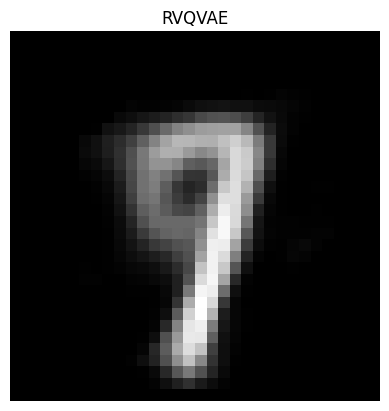

In [ ]:
generated_index = 150
image, labels = test_dataset[generated_index]
image = image.unsqueeze(0).to(device)

_,_, rvqvae_reconstructed, *_ = linear_rvq(image)

image = image.to("cpu")
rvqvae_reconstructed = rvqvae_reconstructed.to("cpu").detach().numpy()

plt.imshow(rvqvae_reconstructed.squeeze(),cmap="gray")
plt.title("RVQVAE")
plt.axis("off")
plt.show()


## Getting Codes

Code Indexes:
tensor([[ 7, 26,  5,  5]])


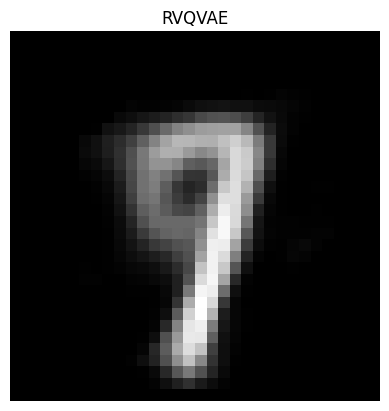

In [ ]:
generated_index = 150
image, label = test_dataset[generated_index]
image = image.unsqueeze(0).to(device)

### Get Codes ###
code_idx = linear_rvq.get_codes(image)
print("Code Indexes:")
print(code_idx)

### Decode Codes ###
decoded = linear_rvq.decode_codes(code_idx)

plt.imshow(rvqvae_reconstructed.squeeze(), cmap="gray")
plt.title("RVQVAE")
plt.axis("off")
plt.show()